# ELEC 576 Assignment 0

Yunfei Xie (yx106)

Python, NumPy, SciPy, and Matplotlib exercises.

## Task 1: Anaconda environment

In [1]:
import subprocess
result = subprocess.run(['conda', 'info'], capture_output=True, text=True, check=True)
print(result.stdout, end='')


     active environment : base
    active env location : /Users/xieyunfei/anaconda3
            shell level : 1
       user config file : /Users/xieyunfei/.condarc
 populated config files : /Users/xieyunfei/anaconda3/.condarc
                          /Users/xieyunfei/anaconda3/condarc.d/anaconda-auth.yml
          conda version : 26.5.3
    conda-build version : 26.5.0
         python version : 3.14.6.final.0
                 solver : libmamba (default)
       virtual packages : __archspec=1=m3
                          __conda=26.5.3=0
                          __osx=15.5=0
                          __unix=0=0
       base environment : /Users/xieyunfei/anaconda3  (writable)
      conda av data dir : /Users/xieyunfei/anaconda3/etc/conda
  conda av metadata url : None
           channel URLs : https://repo.anaconda.com/pkgs/main/osx-arm64
                          https://repo.anaconda.com/pkgs/main/noarch
                          https://repo.anaconda.com/pkgs/r/osx-arm64
          

## Task 2: Linear algebra equivalents

The numbered examples follow all 82 rows of the [NumPy table](https://numpy.org/doc/stable/user/numpy-for-matlab-users.html#linear-algebra-equivalents). The matrices and supporting examples are defined below.

In [2]:
import numpy as np
import scipy
import scipy.linalg
from scipy import linalg, signal
from scipy.sparse.linalg import cg, eigs
from numpy.random import default_rng
np.set_printoptions(precision=6, suppress=True, linewidth=76, threshold=10000)
small = np.array([[3., 1.], [2., 4.]])
other = np.array([[2., 3.], [5., 2.]])
scan = np.arange(1., 46.).reshape(5, 9)
threshold = np.array([[0.2, 0.7, 0.5], [0.9, 0.4, 0.8]])
complex_matrix = np.array([[1+2j, 3-1j], [2j, 4+0j]])
spd = np.array([[6., 2., 1.], [2., 5., 2.], [1., 2., 4.]])
rect = np.array([[1., 0.], [1., 1.], [1., 2.]])
for name in ['small', 'other', 'scan', 'threshold', 'complex_matrix', 'spd', 'rect']:
    print(name + ' =')
    print(globals()[name])


small =
[[3. 1.]
 [2. 4.]]
other =
[[2. 3.]
 [5. 2.]]
scan =
[[ 1.  2.  3.  4.  5.  6.  7.  8.  9.]
 [10. 11. 12. 13. 14. 15. 16. 17. 18.]
 [19. 20. 21. 22. 23. 24. 25. 26. 27.]
 [28. 29. 30. 31. 32. 33. 34. 35. 36.]
 [37. 38. 39. 40. 41. 42. 43. 44. 45.]]
threshold =
[[0.2 0.7 0.5]
 [0.9 0.4 0.8]]
complex_matrix =
[[1.+2.j 3.-1.j]
 [0.+2.j 4.+0.j]]
spd =
[[6. 2. 1.]
 [2. 5. 2.]
 [1. 2. 4.]]
rect =
[[1. 0.]
 [1. 1.]
 [1. 2.]]


### 2.1 Dimensions

In [3]:
a = small.copy()
print(np.ndim(a))
print(a.ndim)


2
2


### 2.2 Number of elements

In [4]:
a = small.copy()
print(np.size(a))
print(a.size)


4
4


### 2.3 Array shape

In [5]:
a = small.copy()
print(np.shape(a))
print(a.shape)


(2, 2)
(2, 2)


### 2.4 Length of one axis

In [6]:
a = scan.copy()
n = 2
print(a.shape[n-1])


9


### 2.5 Create an array

In [7]:
a = np.array([[1., 2., 3.], [4., 5., 6.]])
print(a)


[[1. 2. 3.]
 [4. 5. 6.]]


### 2.6 Assemble blocks

In [8]:
a, b = small.copy(), other.copy()
c, d = np.eye(2), np.zeros((2, 2))
print(np.block([[a, b], [c, d]]))


[[3. 1. 2. 3.]
 [2. 4. 5. 2.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]]


### 2.7 Last vector entry

In [9]:
a = np.array([4., 9., 16.])
print(a[-1])


16.0


### 2.8 One matrix entry

In [10]:
a = scan.copy()
print(a[1, 4])


14.0


### 2.9 One row

In [11]:
a = scan.copy()
print(a[1])
print(a[1, :])


[10. 11. 12. 13. 14. 15. 16. 17. 18.]
[10. 11. 12. 13. 14. 15. 16. 17. 18.]


### 2.10 First five rows

In [12]:
a = scan.copy()
print(a[0:5])
print(a[:5])
print(a[0:5, :])


[[ 1.  2.  3.  4.  5.  6.  7.  8.  9.]
 [10. 11. 12. 13. 14. 15. 16. 17. 18.]
 [19. 20. 21. 22. 23. 24. 25. 26. 27.]
 [28. 29. 30. 31. 32. 33. 34. 35. 36.]
 [37. 38. 39. 40. 41. 42. 43. 44. 45.]]
[[ 1.  2.  3.  4.  5.  6.  7.  8.  9.]
 [10. 11. 12. 13. 14. 15. 16. 17. 18.]
 [19. 20. 21. 22. 23. 24. 25. 26. 27.]
 [28. 29. 30. 31. 32. 33. 34. 35. 36.]
 [37. 38. 39. 40. 41. 42. 43. 44. 45.]]
[[ 1.  2.  3.  4.  5.  6.  7.  8.  9.]
 [10. 11. 12. 13. 14. 15. 16. 17. 18.]
 [19. 20. 21. 22. 23. 24. 25. 26. 27.]
 [28. 29. 30. 31. 32. 33. 34. 35. 36.]
 [37. 38. 39. 40. 41. 42. 43. 44. 45.]]


### 2.11 Last five rows

In [13]:
a = np.arange(1., 15.).reshape(7, 2)
print(a)
print(a[-5:])


[[ 1.  2.]
 [ 3.  4.]
 [ 5.  6.]
 [ 7.  8.]
 [ 9. 10.]
 [11. 12.]
 [13. 14.]]
[[ 5.  6.]
 [ 7.  8.]
 [ 9. 10.]
 [11. 12.]
 [13. 14.]]


### 2.12 A rectangular slice

In [14]:
a = scan.copy()
print(a[0:3, 4:9])


[[ 5.  6.  7.  8.  9.]
 [14. 15. 16. 17. 18.]
 [23. 24. 25. 26. 27.]]


### 2.13 Selected rows and columns

In [15]:
a = scan.copy()
print(a[np.ix_([1, 3, 4], [0, 2])])


[[10. 12.]
 [28. 30.]
 [37. 39.]]


### 2.14 Rows 3 through 21 with a stride of two

In [16]:
a = np.arange(1., 22.).reshape(21, 1)
print(a[2:21:2, :])


[[ 3.]
 [ 5.]
 [ 7.]
 [ 9.]
 [11.]
 [13.]
 [15.]
 [17.]
 [19.]
 [21.]]


### 2.15 Every other row

In [17]:
a = scan.copy()
print(a[::2, :])


[[ 1.  2.  3.  4.  5.  6.  7.  8.  9.]
 [19. 20. 21. 22. 23. 24. 25. 26. 27.]
 [37. 38. 39. 40. 41. 42. 43. 44. 45.]]


### 2.16 Reverse the rows

In [18]:
a = small.copy()
print(a[::-1, :])


[[2. 4.]
 [3. 1.]]


### 2.17 Append the first row

In [19]:
a = small.copy()
print(a[np.r_[:len(a), 0]])


[[3. 1.]
 [2. 4.]
 [3. 1.]]


### 2.18 Transpose

In [20]:
a = small.copy()
print(a.transpose())
print(a.T)


[[3. 2.]
 [1. 4.]]
[[3. 2.]
 [1. 4.]]


### 2.19 Conjugate transpose

In [21]:
a = complex_matrix.copy()
print(a.conj().transpose())
print(a.conj().T)


[[1.-2.j 0.-2.j]
 [3.+1.j 4.-0.j]]
[[1.-2.j 0.-2.j]
 [3.+1.j 4.-0.j]]


### 2.20 Matrix multiplication

In [22]:
a, b = small.copy(), other.copy()
print(a @ b)


[[11. 11.]
 [24. 14.]]


### 2.21 Elementwise multiplication

In [23]:
a, b = small.copy(), other.copy()
print(a * b)


[[ 6.  3.]
 [10.  8.]]


### 2.22 Elementwise division

In [24]:
a, b = small.copy(), other.copy()
print(a / b)


[[1.5      0.333333]
 [0.4      2.      ]]


### 2.23 Elementwise powers

In [25]:
a = small.copy()
print(a**3)


[[27.  1.]
 [ 8. 64.]]


### 2.24 A Boolean comparison

In [26]:
a = threshold.copy()
print(a > 0.5)


[[False  True False]
 [ True False  True]]


### 2.25 Indices satisfying a condition

In [27]:
a = threshold.copy()
print(np.nonzero(a > 0.5))


(array([0, 1, 1]), array([1, 0, 2]))


### 2.26 Select columns using index positions

In [28]:
a = threshold.copy()
v = np.array([0.3, 0.9, 0.7])
print(a[:, np.nonzero(v > 0.5)[0]])


[[0.7 0.5]
 [0.4 0.8]]


### 2.27 Select columns using a Boolean mask

The first call uses a one-dimensional vector. For a two-dimensional column vector, ravel() produces a one-dimensional column mask.

In [29]:
a = threshold.copy()
v = np.array([0.3, 0.9, 0.7])
print(a[:, v.T > 0.5])
v = v.reshape(-1, 1)
print(a[:, v.ravel() > 0.5])


[[0.7 0.5]
 [0.4 0.8]]
[[0.7 0.5]
 [0.4 0.8]]


### 2.28 Replace entries below a threshold

In [30]:
a = threshold.copy()
a[a < 0.5] = 0
print(a)


[[0.  0.7 0.5]
 [0.9 0.  0.8]]


### 2.29 Multiply by a strict Boolean mask

The entry equal to 0.5 becomes zero here. It remains 0.5 in the previous example because that assignment tests a < 0.5.

In [31]:
a = threshold.copy()
print(a * (a > 0.5))


[[0.  0.7 0. ]
 [0.9 0.  0.8]]


### 2.30 Fill an array

In [32]:
a = small.copy()
a[:] = 3
print(a)


[[3. 3.]
 [3. 3.]]


### 2.31 Copy an array

Changing the copy leaves x unchanged.

In [33]:
x = small.copy()
y = x.copy()
y[0, 0] = 99
print(y)
print(x)


[[99.  1.]
 [ 2.  4.]]
[[3. 1.]
 [2. 4.]]


### 2.32 Copy a row

In [34]:
x = small.copy()
y = x[1, :].copy()
y[0] = 99
print(y)
print(x)


[99.  4.]
[[3. 1.]
 [2. 4.]]


### 2.33 Flatten an array

The default traversal reads rows first. The F option reads columns first, matching MATLAB linear indexing.

In [35]:
x = small.copy()
y = x.flatten()
print(y)
print(x.flatten("F"))


[3. 1. 2. 4.]
[3. 2. 1. 4.]


### 2.34 The values 1 through 10

In [36]:
print(np.arange(1., 11.))
print(np.r_[1.:11.])
print(np.r_[1:10:10j])


[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


### 2.35 The values 0 through 9

In [37]:
print(np.arange(10.))
print(np.r_[:10.])
print(np.r_[:9:10j])


[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]


### 2.36 A column vector

In [38]:
print(np.arange(1., 11.)[:, np.newaxis])


[[ 1.]
 [ 2.]
 [ 3.]
 [ 4.]
 [ 5.]
 [ 6.]
 [ 7.]
 [ 8.]
 [ 9.]
 [10.]]


### 2.37 A zero matrix

In [39]:
print(np.zeros((3, 4)))


[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


### 2.38 A three-dimensional zero array

In [40]:
print(np.zeros((3, 4, 5)))


[[[0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]]]


### 2.39 An array of ones

In [41]:
print(np.ones((3, 4)))


[[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]


### 2.40 An identity matrix

In [42]:
print(np.eye(3))


[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


### 2.41 Read a diagonal

In [43]:
a = small.copy()
print(np.diag(a))


[3. 4.]


### 2.42 Construct a diagonal matrix

In [44]:
v = np.array([2., 5., 8.])
print(np.diag(v, 0))


[[2. 0. 0.]
 [0. 5. 0.]
 [0. 0. 8.]]


### 2.43 Random values with a fixed seed

The table passes a tuple to rand, which expects separate dimension arguments. The working call is random.rand(3, 4). The two generators use different random streams.

In [45]:
from numpy.random import default_rng
rng = default_rng(42)
print(rng.random((3, 4)))
from numpy import random
random.seed(42)
try:
    random.rand((3, 4))
except TypeError as error:
    print(type(error).__name__ + ": " + str(error))
print(random.rand(3, 4))


[[0.773956 0.438878 0.858598 0.697368]
 [0.094177 0.975622 0.76114  0.786064]
 [0.128114 0.450386 0.370798 0.926765]]
TypeError: 'tuple' object cannot be interpreted as an integer
[[0.37454  0.950714 0.731994 0.598658]
 [0.156019 0.155995 0.058084 0.866176]
 [0.601115 0.708073 0.020584 0.96991 ]]


### 2.44 Evenly spaced values

In [46]:
print(np.linspace(1, 3, 4))


[1.       1.666667 2.333333 3.      ]


### 2.45 Dense coordinate grids

mgrid returns arrays shaped (9, 6); meshgrid uses (6, 9) with its default xy indexing.

In [47]:
print(np.mgrid[0:9., 0:6.])
print(np.meshgrid(np.r_[0:9.], np.r_[0:6.]))


[[[0. 0. 0. 0. 0. 0.]
  [1. 1. 1. 1. 1. 1.]
  [2. 2. 2. 2. 2. 2.]
  [3. 3. 3. 3. 3. 3.]
  [4. 4. 4. 4. 4. 4.]
  [5. 5. 5. 5. 5. 5.]
  [6. 6. 6. 6. 6. 6.]
  [7. 7. 7. 7. 7. 7.]
  [8. 8. 8. 8. 8. 8.]]

 [[0. 1. 2. 3. 4. 5.]
  [0. 1. 2. 3. 4. 5.]
  [0. 1. 2. 3. 4. 5.]
  [0. 1. 2. 3. 4. 5.]
  [0. 1. 2. 3. 4. 5.]
  [0. 1. 2. 3. 4. 5.]
  [0. 1. 2. 3. 4. 5.]
  [0. 1. 2. 3. 4. 5.]
  [0. 1. 2. 3. 4. 5.]]]
(array([[0., 1., 2., 3., 4., 5., 6., 7., 8.],
       [0., 1., 2., 3., 4., 5., 6., 7., 8.],
       [0., 1., 2., 3., 4., 5., 6., 7., 8.],
       [0., 1., 2., 3., 4., 5., 6., 7., 8.],
       [0., 1., 2., 3., 4., 5., 6., 7., 8.],
       [0., 1., 2., 3., 4., 5., 6., 7., 8.]]), array([[0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [2., 2., 2., 2., 2., 2., 2., 2., 2.],
       [3., 3., 3., 3., 3., 3., 3., 3., 3.],
       [4., 4., 4., 4., 4., 4., 4., 4., 4.],
       [5., 5., 5., 5., 5., 5., 5., 5., 5.]]))


### 2.46 Open coordinate grids

The table's ix_ call is missing a closing parenthesis. The example includes it.

In [48]:
print(np.ogrid[0:9., 0:6.])
print(np.ix_(np.r_[0:9.], np.r_[0:6.]))


(array([[0.],
       [1.],
       [2.],
       [3.],
       [4.],
       [5.],
       [6.],
       [7.],
       [8.]]), array([[0., 1., 2., 3., 4., 5.]]))
(array([[0.],
       [1.],
       [2.],
       [3.],
       [4.],
       [5.],
       [6.],
       [7.],
       [8.]]), array([[0., 1., 2., 3., 4., 5.]]))


### 2.47 An irregular dense grid

In [49]:
print(np.meshgrid([1, 2, 4], [2, 4, 5]))


(array([[1, 2, 4],
       [1, 2, 4],
       [1, 2, 4]]), array([[2, 2, 2],
       [4, 4, 4],
       [5, 5, 5]]))


### 2.48 An irregular open grid

In [50]:
print(np.ix_([1, 2, 4], [2, 4, 5]))


(array([[1],
       [2],
       [4]]), array([[2, 4, 5]]))


### 2.49 Repeat a matrix

In [51]:
a = small.copy()
m, n = 2, 3
print(np.tile(a, (m, n)))


[[3. 1. 3. 1. 3. 1.]
 [2. 4. 2. 4. 2. 4.]
 [3. 1. 3. 1. 3. 1.]
 [2. 4. 2. 4. 2. 4.]]


### 2.50 Join columns

In [52]:
a, b = small.copy(), other.copy()
print(np.concatenate((a, b), 1))
print(np.hstack((a, b)))
print(np.column_stack((a, b)))
print(np.c_[a, b])


[[3. 1. 2. 3.]
 [2. 4. 5. 2.]]
[[3. 1. 2. 3.]
 [2. 4. 5. 2.]]
[[3. 1. 2. 3.]
 [2. 4. 5. 2.]]
[[3. 1. 2. 3.]
 [2. 4. 5. 2.]]


### 2.51 Join rows

In [53]:
a, b = small.copy(), other.copy()
print(np.concatenate((a, b)))
print(np.vstack((a, b)))
print(np.r_[a, b])


[[3. 1.]
 [2. 4.]
 [2. 3.]
 [5. 2.]]
[[3. 1.]
 [2. 4.]
 [2. 3.]
 [5. 2.]]
[[3. 1.]
 [2. 4.]
 [2. 3.]
 [5. 2.]]


### 2.52 Maximum over all entries

nanmax ignores the inserted NaN, while max propagates it.

In [54]:
a = small.copy()
print(a.max())
print(np.nanmax(a))
a[0, 0] = np.nan
print(a.max())
print(np.nanmax(a))


4.0
4.0
nan
4.0


### 2.53 Maximum in each column

In [55]:
a = small.copy()
print(a.max(0))


[3. 4.]


### 2.54 Maximum in each row

In [56]:
a = small.copy()
print(a.max(1))


[3. 4.]


### 2.55 Elementwise maximum

In [57]:
a, b = small.copy(), other.copy()
print(np.maximum(a, b))


[[3. 3.]
 [5. 4.]]


### 2.56 Euclidean norm

In [58]:
v = np.array([3., 4.])
print(np.sqrt(v @ v))
print(np.linalg.norm(v))


5.0
5.0


### 2.57 Logical AND

In [59]:
a = np.array([0, 2, 3, 0])
b = np.array([1, 1, 0, 0])
print(np.logical_and(a, b))


[False  True False False]


### 2.58 Logical OR

In [60]:
a = np.array([0, 2, 3, 0])
b = np.array([1, 1, 0, 0])
print(np.logical_or(a, b))


[ True  True  True False]


### 2.59 Bitwise AND

In [61]:
a = np.array([0, 2, 3, 0])
b = np.array([1, 1, 0, 0])
print(a & b)


[0 0 0 0]


### 2.60 Bitwise OR

In [62]:
a = np.array([0, 2, 3, 0])
b = np.array([1, 1, 0, 0])
print(a | b)


[1 3 3 0]


### 2.61 Matrix inverse

In [63]:
a = small.copy()
print(linalg.inv(a))


[[ 0.4 -0.1]
 [-0.2  0.3]]


### 2.62 Pseudoinverse

In [64]:
a = rect.copy()
print(linalg.pinv(a))


[[ 0.833333  0.333333 -0.166667]
 [-0.5      -0.        0.5     ]]


### 2.63 Matrix rank

In [65]:
a = np.array([[1., 2., 3.], [2., 4., 6.], [1., 1., 1.]])
print(a)
print(np.linalg.matrix_rank(a))


[[1. 2. 3.]
 [2. 4. 6.]
 [1. 1. 1.]]
2


### 2.64 Square and rectangular linear systems

lstsq returns the solution, residual sum of squares, rank, and singular values.

In [66]:
a = spd.copy()
b = np.array([1., 2., 3.])
print(linalg.solve(a, b))
a = rect.copy()
b = np.array([1., 2., 2.])
print(linalg.lstsq(a, b))


[0.012048 0.120482 0.686747]
(array([1.166667, 0.5     ]), array(0.166667), np.int64(2), array([2.676243, 0.915272]))


### 2.65 A system with the unknown on the left

Transposing x a = b gives a.T x.T = b.T.

In [67]:
a = small.copy()
b = np.array([[1., 2.], [4., 3.]])
x = linalg.solve(a.T, b.T).T
print(x)
print(x @ a)


[[0.  0.5]
 [1.  0.5]]
[[1. 2.]
 [4. 3.]]


### 2.66 Singular value decomposition

The inputs are real, so Vh.T gives V. A complex input would require Vh.conj().T.

In [68]:
a = rect.copy()
U, S, Vh = linalg.svd(a)
V = Vh.T
print(U)
print(S)
print(V)


[[-0.218482  0.88634   0.408248]
 [-0.521609  0.247502 -0.816497]
 [-0.824736 -0.391336  0.408248]]
[2.676243 0.915272]
[[-0.58471   0.811242]
 [-0.811242 -0.58471 ]]


### 2.67 Cholesky factorization

SciPy returns an upper triangular factor by default, so a = U.T @ U for this real matrix.

In [69]:
a = spd.copy()
print(linalg.cholesky(a))


[[2.44949  0.816497 0.408248]
 [0.       2.081666 0.800641]
 [0.       0.       1.786703]]


### 2.68 Eigenvalues and eigenvectors

In [70]:
a = spd.copy()
D, V = linalg.eig(a)
print(D)
print(V)


[8.504664+0.j 4.135359+0.j 2.359977+0.j]
[[ 0.6626    0.728518  0.173846]
 [ 0.618866 -0.401808 -0.674948]
 [ 0.421859 -0.554808  0.717093]]


### 2.69 Generalized eigenvalues

Each column v satisfies a @ v = lambda * b @ v.

In [71]:
a = spd.copy()
b = np.diag([1., 2., 3.])
D, V = linalg.eig(a, b)
print(D)
print(V)


[6.627658+0.j 2.297011+0.j 0.908665+0.j]
[[ 0.962317 -0.516738  0.05554 ]
 [ 0.255615  0.777256 -0.556036]
 [ 0.092775  0.358963  0.8293  ]]


### 2.70 Three eigenpairs of a larger matrix

The fixed starting vector makes the iterative calculation reproducible. The three largest magnitudes are 13, 11, and 7.

In [72]:
a = np.diag([2., 3., 5., 7., 11., 13.])
D, V = eigs(a, k=3, v0=np.ones(6))
print(D)
print(V)


[13.+0.j 11.+0.j  7.+0.j]
[[ 0.+0.j  0.+0.j -0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j -0.+0.j]
 [ 0.+0.j  0.+0.j  1.+0.j]
 [-0.+0.j  1.+0.j -0.+0.j]
 [-1.+0.j -0.+0.j -0.+0.j]]


### 2.71 QR factorization

The economic form matches the dimensions requested by MATLAB qr(a, 0).

In [73]:
a = rect.copy()
Q, R = linalg.qr(a)
print(Q)
print(R)
Q, R = linalg.qr(a, mode="economic")
print(Q)
print(R)


[[-0.57735   0.707107  0.408248]
 [-0.57735   0.       -0.816497]
 [-0.57735  -0.707107  0.408248]]
[[-1.732051 -1.732051]
 [ 0.       -1.414214]
 [ 0.        0.      ]]
[[-0.57735   0.707107]
 [-0.57735   0.      ]
 [-0.57735  -0.707107]]
[[-1.732051 -1.732051]
 [ 0.       -1.414214]]


### 2.72 LU factorization

SciPy uses a = P @ L @ U.

In [74]:
a = small.copy()
P, L, U = linalg.lu(a)
print(P)
print(L)
print(U)
print(P @ L @ U)


[[1. 0.]
 [0. 1.]]
[[1.       0.      ]
 [0.666667 1.      ]]
[[3.       1.      ]
 [0.       3.333333]]
[[3. 1.]
 [2. 4.]]


### 2.73 Conjugate gradients

The matrix is symmetric positive definite. A status of zero indicates convergence.

In [75]:
a = spd.copy()
b = np.array([1., 2., 3.])
x, info = cg(a, b, rtol=1e-12, atol=0.0)
print(x)
print(info)


[0.012048 0.120482 0.686747]
0


### 2.74 Discrete Fourier transform

In [76]:
a = np.array([1., 2., 3., 4.])
print(np.fft.fft(a))


[10.+0.j -2.+2.j -2.+0.j -2.-2.j]


### 2.75 Inverse Fourier transform

In [77]:
a = np.fft.fft(np.array([1., 2., 3., 4.]))
print(np.fft.ifft(a))


[1.+0.j 2.+0.j 3.+0.j 4.+0.j]


### 2.76 Default sorting and column sorting

np.sort(a) sorts along the last axis by default. The in-place axis=0 call sorts each column.

In [78]:
a = small.copy()
print(np.sort(a))
a.sort(axis=0)
print(a)


[[1. 3.]
 [2. 4.]]
[[2. 1.]
 [3. 4.]]


### 2.77 Sort each row

In [79]:
a = small.copy()
print(np.sort(a, axis=1))
a.sort(axis=1)
print(a)


[[1. 3.]
 [2. 4.]]
[[1. 3.]
 [2. 4.]]


### 2.78 Sort rows by their first entry

In [80]:
a = np.array([[3., 1.], [1., 4.], [2., 0.]])
I = np.argsort(a[:, 0])
b = a[I, :]
print(I)
print(b)


[1 2 0]
[[1. 4.]
 [2. 0.]
 [3. 1.]]


### 2.79 Linear regression

The fitted line has intercept 7/6 and slope 1/2. The first item of the returned tuple contains those coefficients.

In [81]:
Z = rect.copy()
y = np.array([1., 2., 2.])
x = linalg.lstsq(Z, y)
print(x)
print(Z @ x[0])


(array([1.166667, 0.5     ]), array(0.166667), np.int64(2), array([2.676243, 0.915272]))
[1.166667 1.666667 2.166667]


### 2.80 Fourier resampling

resample requires an integer output length and assumes periodic input. It uses Fourier resampling; decimate uses a different filtering algorithm.

In [82]:
t = np.arange(12.) / 12
x = np.sin(2 * np.pi * t)
q = 3
try:
    signal.resample(x, np.ceil(len(x)/q))
except TypeError as error:
    print(type(error).__name__ + ": " + str(error))
print(signal.resample(x, int(np.ceil(len(x)/q))))


TypeError: slice indices must be integers or None or have an __index__ method
[-0.  1.  0. -1.]


### 2.81 Unique values

In [83]:
a = np.array([4, 1, 4, 2, 1, 3])
print(np.unique(a))


[1 2 3 4]


### 2.82 Remove axes of length one

In [84]:
a = np.array([[[2., 4., 6.]]])
print(a.shape)
print(a.squeeze())
print(a.squeeze().shape)


(1, 1, 3)
[2. 4. 6.]
(3,)


## Optional NumPy practice

These examples use broadcasting, reductions, Boolean indexing, and slicing from the [Stanford tutorial](https://cs231n.github.io/python-numpy-tutorial/).

In [85]:
import numpy as np

points = np.array([[0., 0.], [3., 4.], [0., 4.]])
differences = points[:, None, :] - points[None, :, :]
distances = np.sqrt(np.sum(differences**2, axis=2))
print("Pairwise distances:")
print(distances)
print("Column means:")
print(points.mean(axis=0))
print("Rows whose distance from the origin is at least four:")
print(points[np.linalg.norm(points, axis=1) >= 4])
original = np.arange(6).reshape(2, 3)
view = original[:, 1:]
copy = view.copy()
view[0, 0] = 99
print("Array after changing a slice:")
print(original)
print("Independent copy:")
print(copy)


Pairwise distances:
[[0. 5. 4.]
 [5. 0. 3.]
 [4. 3. 0.]]
Column means:
[1.       2.666667]
Rows whose distance from the origin is at least four:
[[3. 4.]
 [0. 4.]]
Array after changing a slice:
[[ 0 99  2]
 [ 3  4  5]]
Independent copy:
[[1 2]
 [4 5]]


In [86]:
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 140

## Task 3: Assigned plot

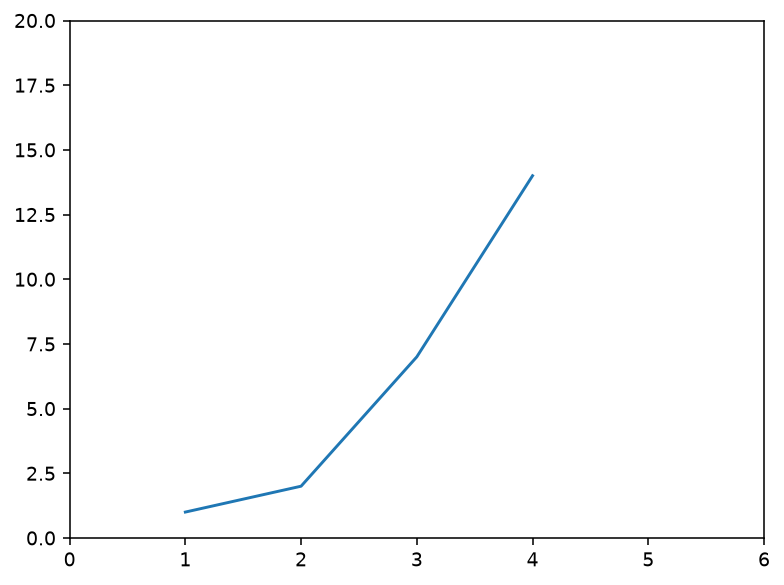

In [87]:
import matplotlib.pyplot as plt
plt.plot([1,2,3,4], [1,2,7,14])
plt.axis([0, 6, 0, 20])
plt.show()


## Task 4: Damped oscillation

The signal is exp(-0.7t) cos(2 pi 1.5t). The dashed curves show its positive and negative envelopes.

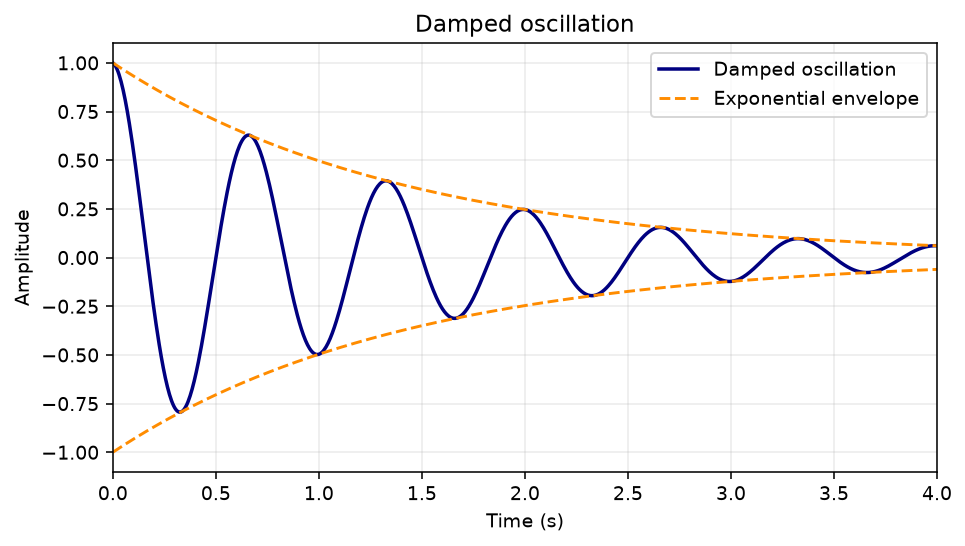

In [88]:
import numpy as np
import matplotlib.pyplot as plt

time = np.linspace(0.0, 4.0, 801)
envelope = np.exp(-0.7 * time)
amplitude = envelope * np.cos(2 * np.pi * 1.5 * time)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(time, amplitude, color="navy", linewidth=1.8,
        label="Damped oscillation")
ax.plot(time, envelope, color="darkorange", linestyle="--",
        label="Exponential envelope")
ax.plot(time, -envelope, color="darkorange", linestyle="--")
ax.set(xlabel="Time (s)", ylabel="Amplitude",
       title="Damped oscillation", xlim=(0, 4), ylim=(-1.1, 1.1))
ax.grid(alpha=0.25)
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()


## Task 5: Version control account

GitHub account: [yunfeixie233](https://github.com/yunfeixie233).

## Task 6: IDE project

The project is configured for Visual Studio Code.

Repository: https://github.com/yunfeixie233/elec576-assignment0-yunfei-xie